# 피자가게 매출 최적화를 위한 데이터 분석 결론

해당 분석은 피자가게 주문 데이터를 기반으로 매출/주문 패턴을 파악하고, 실행 가능한 개선 아이디어를 도출하는 것을 목표로 합니다.

분석 질문

* 월별 매출은 어떻게 변하는가?
* 요일/시간대별 주문 피크는 언제인가?
* 어떤 메뉴/사이즈가 매출을 주도하는가?
* 결과를 운영(인력/재고/프로모션) 관점에서 어떻게 활용할 수 있는가?


주의

* 데이터에는 날씨/프로모션/지역/배달앱 노출 등 외부 요인이 포함되지 않아, 인과관계(원인 단정)에는 한계가 있습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path(".")
ORDERS_PATH = DATA_DIR / "orders.csv"
PIZZAS_PATH = DATA_DIR / "pizzas.csv"
TYPES_PATH = DATA_DIR / "pizza_types.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [2]:
# 1) 데이터 로드
orders = pd.read_csv(ORDERS_PATH)
pizzas = pd.read_csv(PIZZAS_PATH)
pizza_types = pd.read_csv(TYPES_PATH)

print("orders:", orders.shape)
print("pizzas:", pizzas.shape)
print("pizza_types:", pizza_types.shape)

orders.head()

orders: (47079, 5)
pizzas: (39, 4)
pizza_types: (13, 3)


,order_id,order_timestamp,order_details_id,pizza_id,quantity
0,1,2023-01-01 11:45:11,1,hawaiian_m,1
1,2,2023-01-01 11:53:26,2,big_meat_l,1
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1
3,2,2023-01-01 11:53:26,4,five_cheese_l,1
4,2,2023-01-01 11:53:26,5,potato_m,1


## 데이터 설명

### orders.csv
- **order_id**: 주문 ID (한 주문에는 여러 메뉴가 포함될 수 있음)
- **order_timestamp**: 주문이 발생한 시각
- **order_details_id**: 주문 상세(라인 아이템) ID
- **pizza_id**: 주문된 피자의 ID
- **quantity**: 주문 수량

### pizzas.csv
- **pizza_id**: 피자 ID
- **pizza_name**: 피자 이름
- **size**: 피자 사이즈 (S / M / L)
- **price**: 피자 가격

### pizza_types.csv
- **pizza_name**: 피자 이름
- **category**: 피자 카테고리
- **ingredients**: 피자의 주요 재료


In [4]:
# 2) 데이터 결합 + 파생변수 생성
df = orders.merge(pizzas, on='pizza_id', how='left')
df['total_price'] = df['quantity'] * df['price']
df = df.merge(pizza_types, on='pizza_name', how='left')

# 시간 변수
df['order_timestamp'] = pd.to_datetime(df['order_timestamp'])
df['date'] = df['order_timestamp'].dt.date
df['month'] = df['order_timestamp'].dt.to_period('M').astype(str)
df['dow'] = df['order_timestamp'].dt.day_name()
df['hour'] = df['order_timestamp'].dt.hour

# 기본 점검
display(df.head())
display(df.isna().sum().sort_values(ascending=False).head(10))

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,total_price,category,ingredients,date,month,dow,hour
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",2023-01-01,2023-01,Sunday,11
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000,34000,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조",2023-01-01,2023-01,Sunday,11
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300,20300,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨",2023-01-01,2023-01,Sunday,11
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000,31000,베지테리언,"모짜렐라 치즈, 프로볼로네 치즈, 고다 치즈, 페코리노 치즈, 고르곤졸라 치즈",2023-01-01,2023-01,Sunday,11
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800,21800,스페셜,"모짜렐라 치즈, 토마토, 감자, 양파, 베이컨, 옥수수, 마요네즈",2023-01-01,2023-01,Sunday,11


order_id            0
order_timestamp     0
order_details_id    0
pizza_id            0
quantity            0
pizza_name          0
size                0
price               0
total_price         0
category            0
dtype: int64

## KPI 정의

- **총매출(Total Revenue)**: `total_price`의 합
- **주문 수(Number of Orders)**: `order_id`의 고유 개수 (주문 단위)
- **판매 수량(Total Quantity Sold)**: `quantity`의 합 (상품/라인아이템 단위 합계)
- **객단가(AOV, Average Order Value)**: 총매출 ÷ 주문 수
- **주문당 평균 수량(Average Items per Order)**: 판매 수량 ÷ 주문 수


In [11]:
# 3) KPI 계산 (주문 단위)
total_revenue = df['total_price'].sum()
n_orders = df['order_id'].nunique()
total_qty = df['quantity'].sum()

aov = total_revenue / n_orders
avg_items_per_order = total_qty / n_orders

kpi = pd.DataFrame({
    '지표': ['총매출', '주문 수', '판매 수량', '객단가(AOV)', '주문당 평균 수량'],
    '값': [
        f'{total_revenue:,.0f}원',
        f'{n_orders:,}건',
        f'{total_qty:,}개',
        f'{aov:,.0f}원',
        f'{avg_items_per_order:.2f}개'
    ]
})

kpi

,지표,값
0,총매출,"1,140,882,200원"
1,주문 수,"21,350건"
2,판매 수량,"49,574개"
3,객단가(AOV),"53,437원"
4,주문당 평균 수량,2.32개


## 핵심 요약 (자동 계산 결과 기반)

아래 분석 섹션에서 월/요일/시간대/메뉴/사이즈 관점의 패턴을 확인하고, 마지막에 실행 가능한 제안을 정리합니다.

,revenue,orders,qty,aov
month,,,,
2023-01,93718700,1788,4079,52415.380313
2023-02,89392300,1665,3923,53689.069069
2023-03,98494600,1850,4280,53240.324324
2023-04,96277400,1806,4164,53309.745293
2023-05,100225300,1853,4358,54088.127361
2023-06,95518100,1782,4110,53601.627385
2023-07,101553600,1913,4377,53086.042865
2023-08,94873600,1859,4188,51034.749866
2023-09,89302500,1651,3876,54089.945488


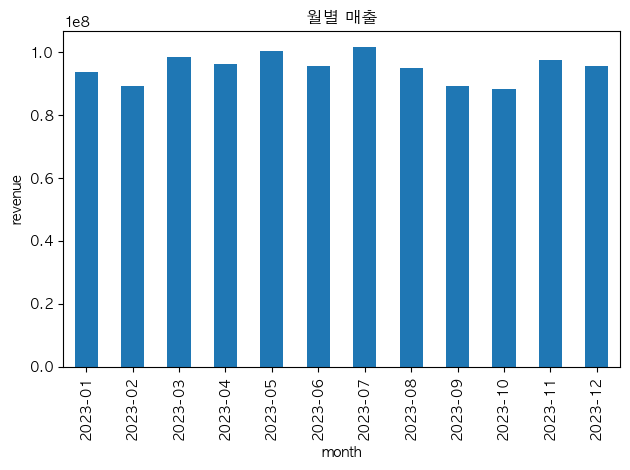

In [14]:
# 4) 월별 트렌드
monthly = df.groupby('month').agg(
    revenue=('total_price', 'sum'),
    orders=('order_id', 'nunique'),
    qty=('quantity', 'sum')
)
monthly['aov'] = monthly['revenue'] / monthly['orders']

display(monthly)

plt.figure()
plt.rcParams["font.family"] = "AppleGothic"
monthly['revenue'].plot(kind='bar')
plt.title('월별 매출')
plt.xlabel('month')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()

,orders,revenue,aov
dow,,,
Monday,2782,147541300,53034.255931
Tuesday,2978,160866900,54018.435191
Wednesday,3065,165848400,54110.407830
Thursday,3166,168921600,53354.895768
Friday,3538,185106800,52319.615602
Saturday,3158,169516300,53678.372388
Sunday,2663,143080900,53729.215171


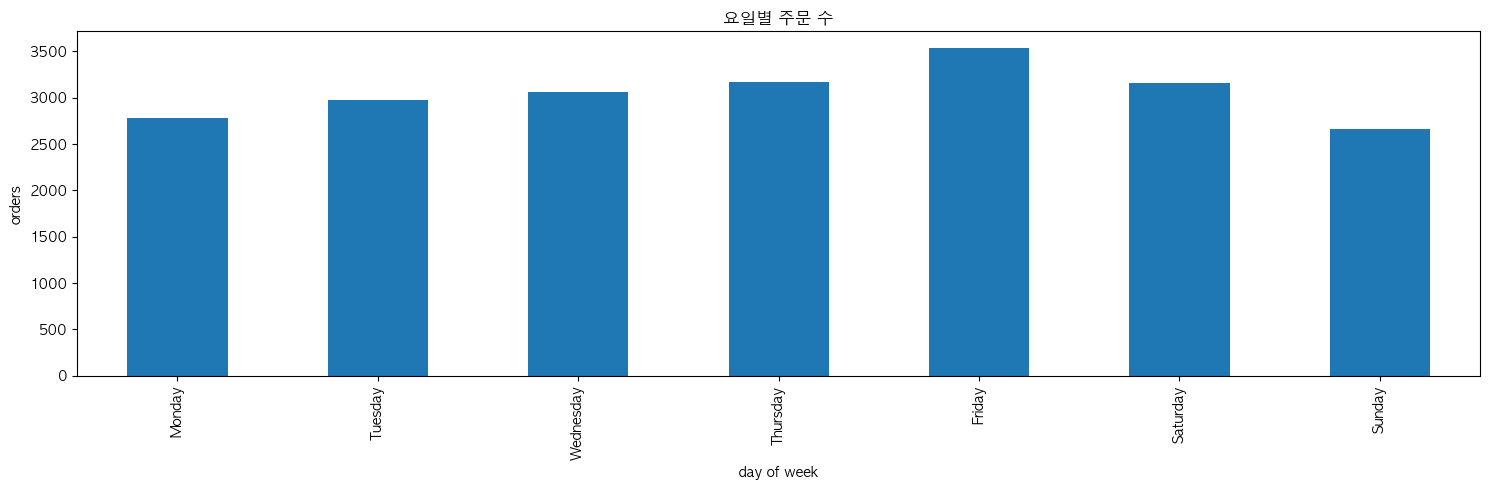

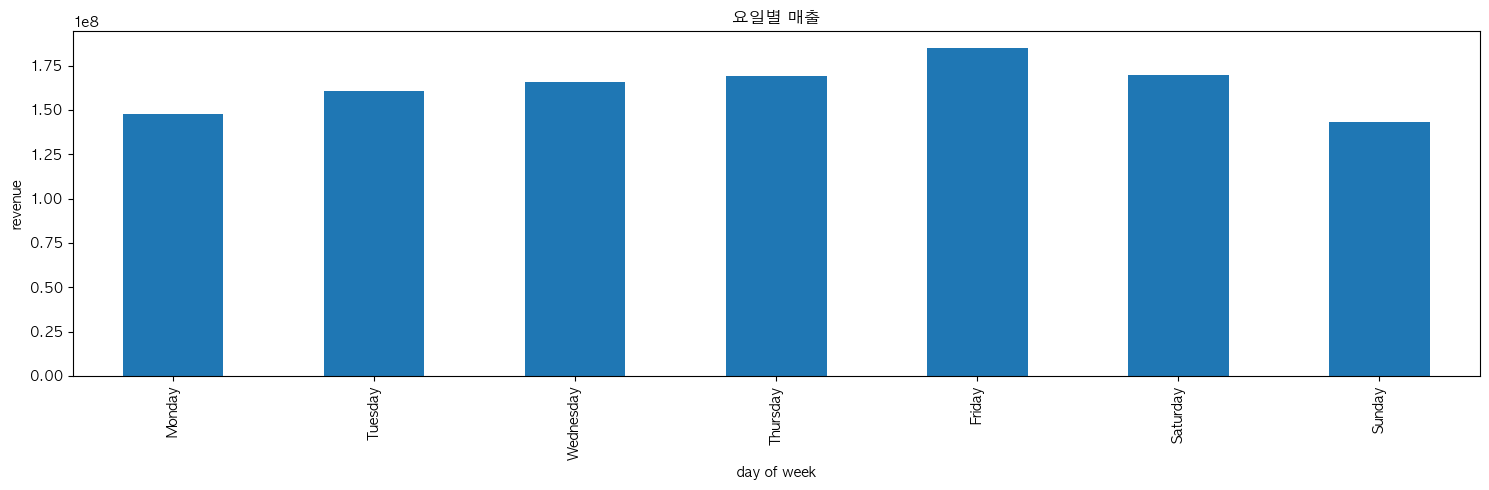

In [19]:
# 5) 요일별 패턴
order_level = df.groupby('order_id').agg(
    order_timestamp=('order_timestamp', 'min'),
    revenue=('total_price', 'sum'),
    qty=('quantity', 'sum')
)
order_level['dow'] = order_level['order_timestamp'].dt.day_name()
order_level['hour'] = order_level['order_timestamp'].dt.hour
order_level['month'] = order_level['order_timestamp'].dt.to_period('M').astype(str)

dow = order_level.groupby('dow').agg(
    orders=('revenue', 'size'),
    revenue=('revenue', 'sum'),
    aov=('revenue', 'mean')
)

order_dow = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = dow.reindex(order_dow)

display(dow)

plt.figure()
dow['orders'].plot(kind='bar')
plt.title('요일별 주문 수')
plt.xlabel('day of week')
plt.ylabel('orders')
plt.tight_layout()
plt.show()

plt.figure()
dow['revenue'].plot(kind='bar')
plt.title('요일별 매출')
plt.xlabel('day of week')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()


## 관찰 포인트
* 주문 수가 높은 요일은 인력/재고를 더 집중해야 하고,
* 주문 수가 낮은 요일은 프로모션(할인/세트/쿠폰)으로 보완하는 전략이 자연스럽다.

,orders,revenue,aov
hour,,,
10,9,461000,51222.222222
11,1231,64896300,52718.359058
12,2520,131185900,52057.896825
13,2455,140566100,57257.067210
14,1472,82838800,56276.358696
15,1468,81688100,55645.844687
16,1920,106494800,55466.041667
17,2336,122837100,52584.375000
18,2399,124612100,51943.351396


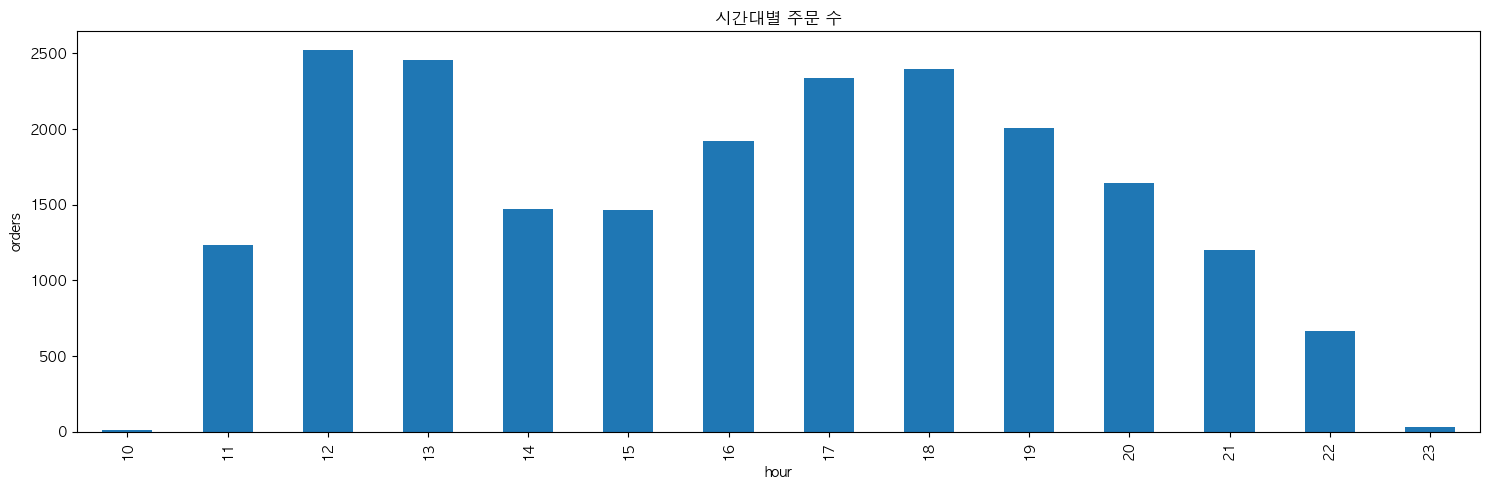

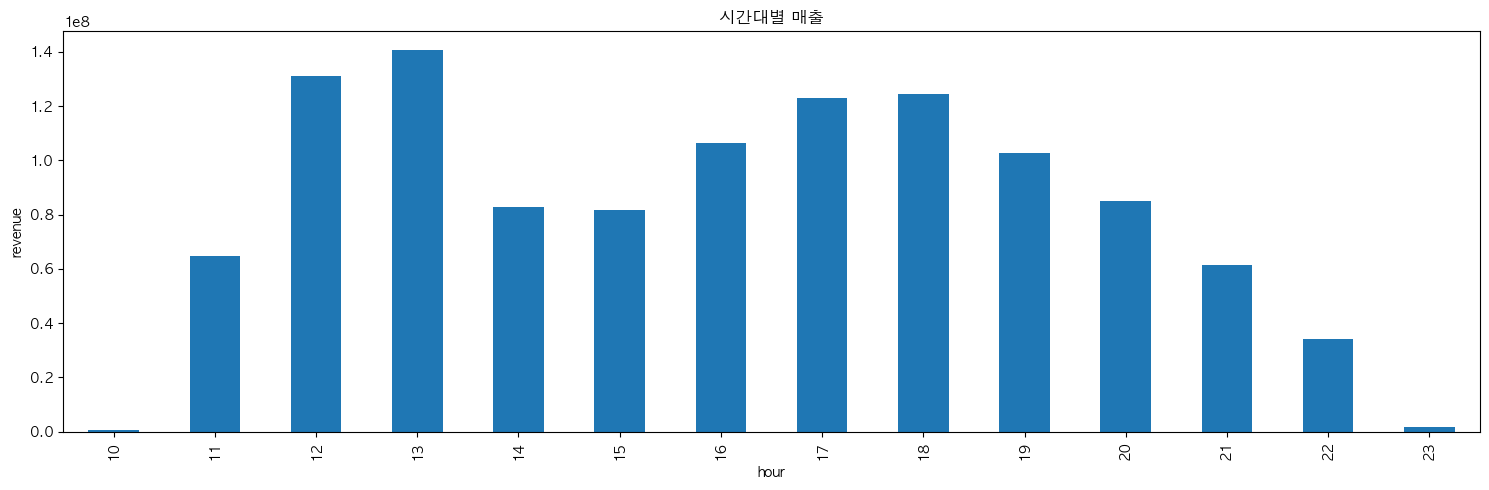

In [22]:
# 6) 시간대별 패턴
hourly = order_level.groupby('hour').agg(
    orders=('revenue','size'),
    revenue=('revenue', 'sum'),
    aov=('revenue', 'mean')
).sort_index()

display(hourly)

plt.figure()
hourly['orders'].plot(kind='bar')
plt.title('시간대별 주문 수')
plt.xlabel('hour')
plt.ylabel('orders')
plt.tight_layout()
plt.show()

plt.figure()
hourly['revenue'].plot(kind='bar')
plt.title('시간대별 매출')
plt.xlabel('hour')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()

,revenue,qty,revenue_share
category,,,
클래식,372362100,18406,0.326381
스페셜,300968100,12825,0.263803
치킨,250183200,9497,0.219289
베지테리언,217368800,8846,0.190527


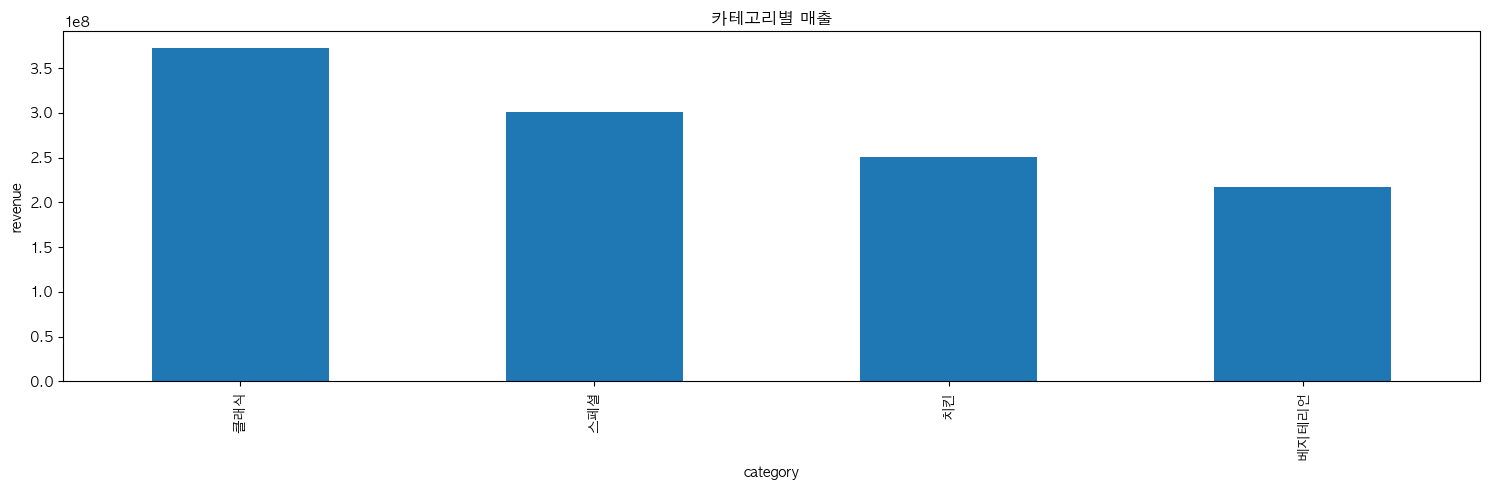

,revenue,qty,revenue_share,qty_share
size,,,,
L,649224400,19536,0.569055,0.394078
M,332504600,15635,0.291445,0.315387
S,159153200,14403,0.139500,0.290535


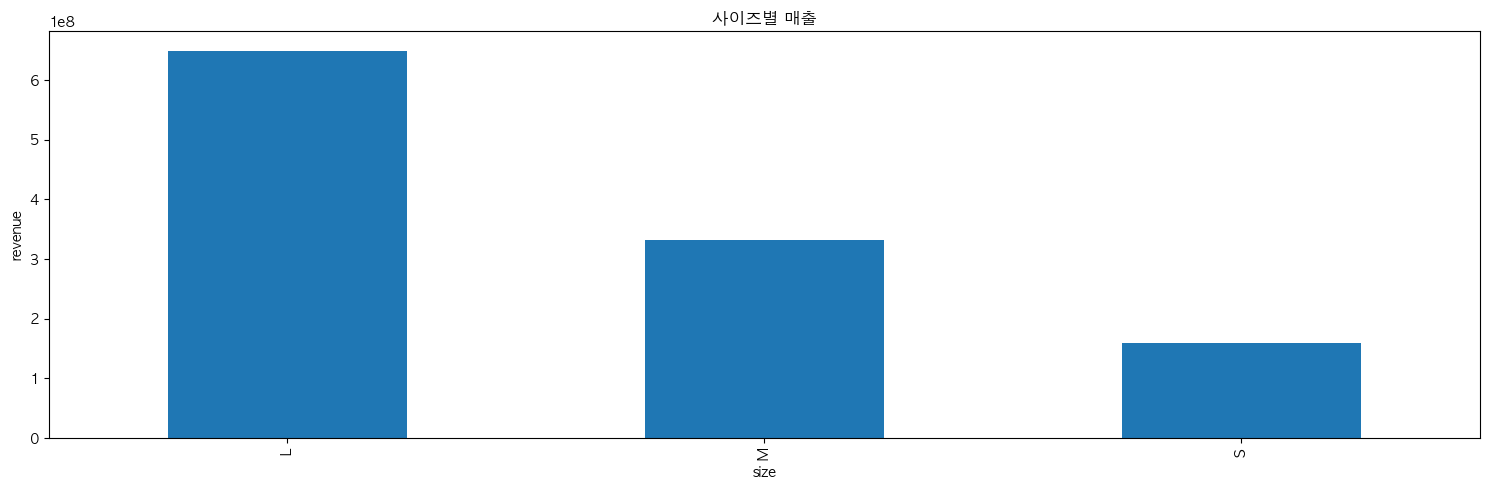

In [23]:
# 7) 카테고리/사이즈 믹스
cat = df.groupby('category').agg(
    revenue=('total_price','sum'),
    qty=('quantity','sum')
).sort_values('revenue', ascending=False)
cat['revenue_share'] = cat['revenue'] / cat['revenue'].sum()
display(cat)

plt.figure()
cat['revenue'].plot(kind='bar')
plt.title('카테고리별 매출')
plt.xlabel('category')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()

size = df.groupby('size').agg(
    revenue=('total_price','sum'),
    qty=('quantity','sum')
).sort_values('revenue', ascending=False)
size['revenue_share'] = size['revenue'] / size['revenue'].sum()
size['qty_share'] = size['qty'] / size['qty'].sum()
display(size)

plt.figure()
size['revenue'].plot(kind='bar')
plt.title('사이즈별 매출')
plt.xlabel('size')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()


,,,revenue,qty
pizza_name,size,category,,
타이 치킨 피자,L,치킨,98771200,2684
하와이안 피자,L,스페셜,86291400,2553
파이브 치즈 피자,L,베지테리언,71269000,2299
페퍼로니 피자,L,클래식,65344700,2309
바비큐 치킨 피자,L,치킨,56916000,1674
포테이토 피자,L,스페셜,46373600,1372
클래식 디럭스 피자,L,클래식,44993900,1393
슈퍼 슈프림 피자,L,클래식,43152800,1336
페퍼로니 피자,M,클래식,40790700,2229


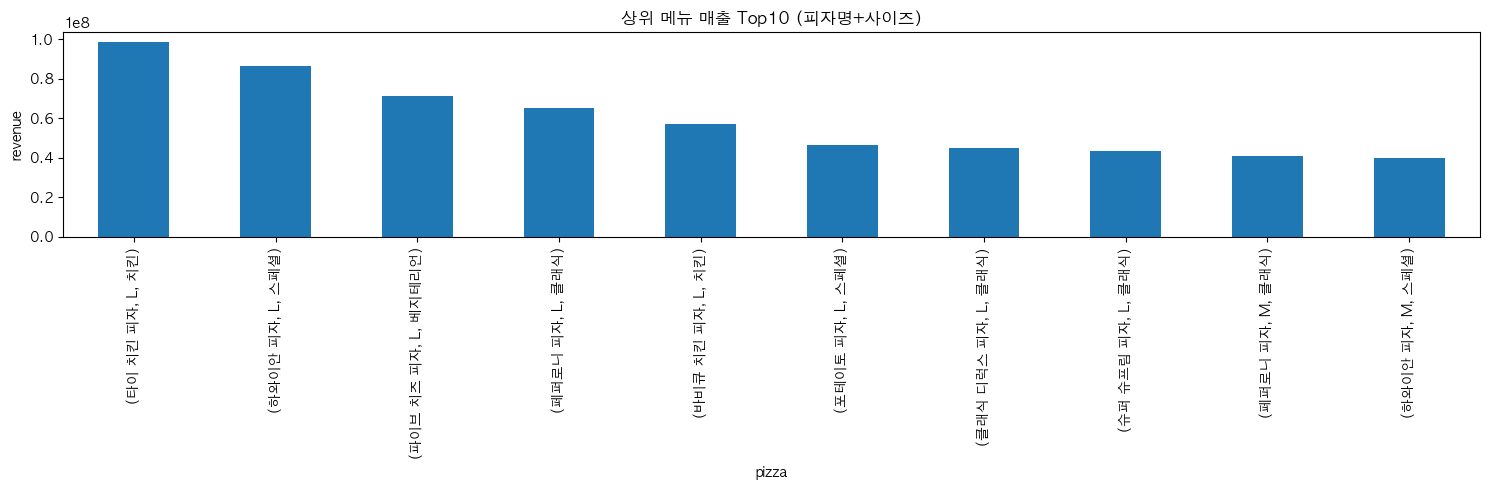

In [24]:
# 8) 상위 메뉴 (매출 기준 Top 10)
top_rev = df.groupby(['pizza_name', 'size', 'category']).agg(
    revenue=('total_price', 'sum'),
    qty=('quantity', 'sum')
).sort_values('revenue', ascending=False).head(10)

display(top_rev)

plt.figure()
top_rev['revenue'].plot(kind='bar')
plt.title('상위 메뉴 매출 Top10 (피자명+사이즈)')
plt.xlabel('pizza')
plt.ylabel('revenue')
plt.tight_layout()
plt.show()

In [25]:
# 9) 주문 피크 시간대(주문 수 기준) 확인
peak_hours = hourly.sort_values('orders', ascending=False).head(5)[['orders','aov']]
pead_dow = dow.sort_values('orders', ascending=False).head(3)[['orders','aov']]

peak_hours, pead_dow

(      orders           aov
 hour                      
 12      2520  52057.896825
 13      2455  57257.067210
 18      2399  51943.351396
 17      2336  52584.375000
 19      2009  51158.984569,
           orders           aov
 dow                           
 Friday      3538  52319.615602
 Thursday    3166  53354.895768
 Saturday    3158  53678.372388)

### 1. 매출 및 주문 패턴 분석 (Key Findings)

- **요일별 편차**  
  금요일이 주문 수(3,538건)와 매출액(약 1.85억 원) 모두에서 압도적인 1위를 차지하며 주간 실적을 견인한다.  
  반면, 일요일과 월요일은 상대적으로 매출이 저조한 양상을 보인다.

- **시간대별 피크**  
  점심(12시-13시)과 저녁(17시-19시)에 주문이 집중되는 쌍봉형(Double Peak) 패턴을 보인다.  
  특히 12시에 주문 건수가 가장 많지만, 13시에는 객단가(AOV)가 약 57,257원으로 가장 높아 점심시간 후반부에 고가 메뉴나 단체 주문이 발생하는 경향이 확인된다.

- **월별 추이**  
  5월과 7월에 매출 정점을 기록하고 9~10월에 하락하는 계절성을 보인다.  
  이는 가정의 달 행사 및 여름 휴가철 수요가 매출에 긍정적인 영향을 미쳤음을 시사한다.

---

### 2. 운영 및 마케팅 제안 (Actionable Insights)

- **인력 및 재고 최적화 (Efficiency)**  
  금요일과 목요일에는 주방 및 배달 인력을 집중 배치하고,  
  화·수요일 대비 재고 비축량을 약 20% 상향 조정하여 기회 손실을 방지할 필요가 있다.  
  또한 매일 12-14시, 17-20시 피크타임에는 ‘빠른 배달’ 중심 운영으로 고객 만족도를 제고해야 한다.

- **AOV 증대 전략 (Profitability)**  
  평균 객단가가 약 53,437원임을 고려할 때,  
  5만 원 미만 주문 고객을 대상으로 사이드 메뉴 할인 또는 음료 세트 업그레이드를 제안하는  
  업셀링 전략이 효과적일 것으로 판단된다.  
  특히 객단가가 높은 13시 시간대 고객을 타겟으로 프리미엄 세트 구성을 강화할 필요가 있다.

- **비수기 타겟 프로모션 (Growth)**  
  주중 매출이 가장 낮은 월요일과 일요일에 한정 프로모션(해피아워, 특가 메뉴)을 운영하여  
  평일 매출의 상향 평준화를 도모해야 한다.  
  매출 하락기인 10월에는 재방문 쿠폰 및 연말 시즌 사전 예약 이벤트를 통해 수요를 선점할 수 있다.

---

### 3. 향후 분석 제언 (Next Steps)

본 분석은 내부 주문 데이터를 기반으로 수행되었으며,  
향후 **날씨 정보(강수/강설 여부)** 및 **배달 플랫폼 프로모션 기간** 데이터를 결합할 경우  
보다 정교한 매출 예측 및 프로모션 효과 분석이 가능할 것으로 기대된다.
